# Summary Statistics: Measuring Centre, Spread, and Shape

## Learning Objectives

By the end of this notebook you will be able to:

1. Compute **measures of central tendency**: mean, median, mode — and explain when each is appropriate.
2. Compute **measures of dispersion**: variance, standard deviation, IQR, range — and the difference between population and sample variance ($n$ vs. $n-1$).
3. Compute **measures of shape**: skewness and kurtosis.
4. Implement each measure **from scratch** in plain Python, then use NumPy/Pandas.
5. Explain why summary statistics alone are **never enough** (Anscombe's quartet).

## Prerequisites

- [Module 01](../01_probability_basics/05_random_variables.ipynb) — $E[X]$, $\text{Var}(X)$
- [Module 02](../02_distributions/02_continuous_distributions.ipynb) — Normal distribution, skewness

In [1]:
import sys, os, shutil
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    os.system(
        "sudo apt-get update -qq && sudo apt-get install -y -qq "
        "libcairo2-dev libpango1.0-dev && pip install -q manim ipython==8.21.0"
    )

_miktex_bin = Path.home() / "AppData/Local/Programs/MiKTeX/miktex/bin/x64"
if _miktex_bin.exists() and str(_miktex_bin) not in os.environ.get("PATH", ""):
    os.environ["PATH"] += os.pathsep + str(_miktex_bin)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath("../../src"))
from amstats.plotting import apply_style

apply_style()


class Cfg:
    root = Path("../../").resolve()
    gif_dir = root / "media" / "gifs"
    has_latex: bool = (
        shutil.which("latex") is not None or shutil.which("pdflatex") is not None
    )

    def __init__(self):
        self.gif_dir.mkdir(parents=True, exist_ok=True)

    def apply_manim_config(self):
        from manim import config as mcfg

        mcfg.format = "gif"

    def math_text(self, expr, **kwargs):
        from manim import MathTex, Text

        if self.has_latex:
            return MathTex(expr, **kwargs)
        return Text(expr, **kwargs)

    def save_gifs(self, clean=True):
        local_media = Path("media")
        found = list(local_media.rglob("*.gif")) if local_media.exists() else []
        if not found:
            print("  No new GIFs to save.")
            return
        for gif in found:
            dest = self.gif_dir / gif.name
            shutil.copy2(gif, dest)
            print(f"  ✓ media/gifs/{gif.name}")
        if clean:
            for sub in ("videos", "images", "Tex"):
                d = local_media / sub
                if d.exists():
                    shutil.rmtree(d, ignore_errors=True)
            print("  Cleaned up local temp render files (kept media/jupyter/).")


cfg = Cfg()
rng = np.random.default_rng(42)

---

## 1. From Population Parameters to Sample Statistics

In Modules 01–02 we studied **theoretical** distributions with known parameters: $\mu$, $\sigma^2$, $\lambda$. In practice, we don't know the true distribution — we have **data** (a sample) and need to *estimate* properties of the underlying population.

| Concept            | Population (theory)        | Sample (data)                                       |
|--------------------|----------------------------|-----------------------------------------------------|
| Mean               | $\mu = E[X]$               | $\bar{x} = \frac{1}{n}\sum_{i=1}^n x_i$             |
| Variance           | $\sigma^2 = \text{Var}(X)$ | $s^2 = \frac{1}{n-1}\sum_{i=1}^n (x_i - \bar{x})^2$ |
| Standard deviation | $\sigma$                   | $s = \sqrt{s^2}$                                    |

The sample statistics are **estimates** of the population parameters. The more data we have, the closer they get (by the LLN). Module 04 will formalise this — for now, we focus on computing and interpreting these quantities.

---

## 2. Measures of Central Tendency

### The Mean

The **arithmetic mean** (or average) is the most common measure of centre:

$$\bar{x} = \frac{1}{n}\sum_{i=1}^n x_i$$

It uses every data point and is the "balance point" of the distribution (as we showed in Module 01, notebook 05). But it is **sensitive to outliers** — a single extreme value can pull it far from the centre of the bulk.

### The Median

The **median** is the middle value when the data is sorted. For $n$ observations:
- If $n$ is odd: the median is the $((n+1)/2)$-th value.
- If $n$ is even: the average of the $(n/2)$-th and $(n/2+1)$-th values.

The median is **robust** — it is barely affected by outliers. For symmetric distributions, mean = median. For skewed distributions, they differ.

### The Mode

The **mode** is the most frequent value (or the peak of the density). It's mainly useful for discrete data or for describing the shape of a distribution (unimodal, bimodal, etc.).

In [2]:
# Stage 2: FROM SCRATCH
def mean_scratch(data):
    """Arithmetic mean using a plain loop."""
    total = 0
    for x in data:
        total += x
    return total / len(data)


def median_scratch(data):
    """Median by sorting."""
    s = sorted(data)
    n = len(s)
    if n % 2 == 1:
        return s[n // 2]
    else:
        return (s[n // 2 - 1] + s[n // 2]) / 2


# Test on clean data
data_clean = [4, 7, 2, 9, 5, 8, 1, 6, 3, 10]
print(f"Data: {data_clean}")
print(f"Mean (scratch):   {mean_scratch(data_clean)}")
print(f"Median (scratch): {median_scratch(data_clean)}")

# Now add an outlier
data_outlier = data_clean + [1000]
print(f"\nWith outlier (1000 added):")
print(f"Mean:   {mean_scratch(data_outlier):.1f}  ← dragged up")
print(f"Median: {median_scratch(data_outlier)}  ← barely moved")

Data: [4, 7, 2, 9, 5, 8, 1, 6, 3, 10]
Mean (scratch):   5.5
Median (scratch): 5.5

With outlier (1000 added):
Mean:   95.9  ← dragged up
Median: 6  ← barely moved


In [3]:
# Stage 3: PROFESSIONAL — NumPy
print(f"np.mean:   {np.mean(data_clean)}")
print(f"np.median: {np.median(data_clean)}")

# NumPy handles edge cases we didn't: NaN, empty arrays, dtypes
data_nan = [1, 2, np.nan, 4]
print(f"\nnp.mean with NaN:    {np.mean(data_nan)}  (NaN propagates!)")
print(f"np.nanmean with NaN: {np.nanmean(data_nan)}  (ignores NaN)")

np.mean:   5.5
np.median: 5.5

np.mean with NaN:    nan  (NaN propagates!)
np.nanmean with NaN: 2.3333333333333335  (ignores NaN)


---

## 3. Measures of Dispersion

### Variance and Standard Deviation

The **sample variance** measures the average squared deviation from the mean:

$$s^2 = \frac{1}{n-1}\sum_{i=1}^n (x_i - \bar{x})^2$$

**Why $n - 1$ and not $n$?** This is called **Bessel's correction**. Dividing by $n$ gives the population variance if we know the true mean $\mu$. But when we estimate $\mu$ with $\bar{x}$, the deviations are systematically too small (because $\bar{x}$ is the value that *minimises* the sum of squared deviations). Dividing by $n - 1$ corrects this bias.

We'll prove this formally in Module 04. For now: **use $n - 1$ for sample data, $n$ for known populations.**

### Interquartile Range (IQR)

The **IQR** is the range of the middle 50% of the data: $\text{IQR} = Q_3 - Q_1$, where $Q_1$ and $Q_3$ are the 25th and 75th percentiles. Like the median, it's robust to outliers.

In [4]:
# Stage 2: FROM SCRATCH
def variance_scratch(data, ddof=1):
    """Sample variance with Bessel's correction (ddof=1) or population (ddof=0)."""
    n = len(data)
    mu = mean_scratch(data)
    ss = 0
    for x in data:
        ss += (x - mu) ** 2
    return ss / (n - ddof)


def std_scratch(data, ddof=1):
    return variance_scratch(data, ddof) ** 0.5


# Generate some data
sample = rng.normal(loc=50, scale=10, size=100)

print(f"From scratch:")
print(f"  mean  = {mean_scratch(sample):.4f}")
print(f"  var   = {variance_scratch(sample):.4f}  (ddof=1, sample variance)")
print(f"  var   = {variance_scratch(sample, ddof=0):.4f}  (ddof=0, population)")
print(f"  std   = {std_scratch(sample):.4f}")

print(f"\nNumPy:")
print(f"  mean  = {np.mean(sample):.4f}")
print(f"  var   = {np.var(sample, ddof=1):.4f}  (ddof=1)")
print(f"  var   = {np.var(sample, ddof=0):.4f}  (ddof=0, NumPy default!)")
print(f"  std   = {np.std(sample, ddof=1):.4f}")

From scratch:
  mean  = 49.4973
  var   = 60.3228  (ddof=1, sample variance)
  var   = 59.7195  (ddof=0, population)
  std   = 7.7668

NumPy:
  mean  = 49.4973
  var   = 60.3228  (ddof=1)
  var   = 59.7195  (ddof=0, NumPy default!)
  std   = 7.7668


**Warning:** NumPy's `np.var()` uses `ddof=0` by default (population variance). Pandas' `.var()` uses `ddof=1` by default (sample variance). This inconsistency catches many people — always be explicit.

---

## 4. Measures of Shape: Skewness and Kurtosis

The mean and variance describe the *location* and *spread* of a distribution. **Skewness** and **kurtosis** describe its *shape*.

### Skewness

$$\text{Skewness} = \frac{1}{n}\sum_{i=1}^n \left(\frac{x_i - \bar{x}}{s}\right)^3$$

- $\text{Skewness} = 0$: symmetric (e.g., Normal)
- $\text{Skewness} > 0$: right-skewed (long right tail — e.g., income, Exponential)
- $\text{Skewness} < 0$: left-skewed (long left tail)

### Kurtosis

$$\text{Kurtosis} = \frac{1}{n}\sum_{i=1}^n \left(\frac{x_i - \bar{x}}{s}\right)^4$$

The Normal distribution has kurtosis = 3. **Excess kurtosis** = kurtosis $- 3$ measures departure from normality:
- Excess $= 0$: Normal-like tails
- Excess $> 0$: heavier tails than Normal ("leptokurtic")
- Excess $< 0$: lighter tails ("platykurtic")

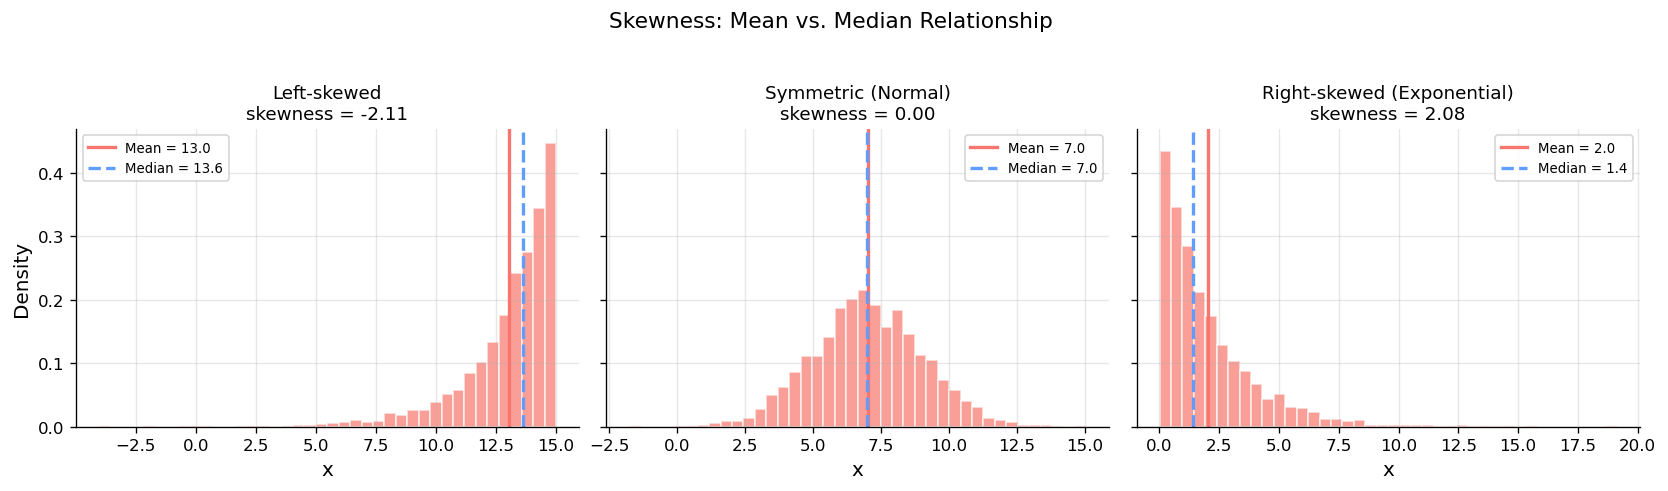

In [5]:
# Visualise skewness with three distributions
from scipy import stats

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)

datasets = {
    "Left-skewed": -rng.exponential(2, 5000) + 15,
    "Symmetric (Normal)": rng.normal(7, 2, 5000),
    "Right-skewed (Exponential)": rng.exponential(2, 5000),
}

for ax, (name, data) in zip(axes, datasets.items()):
    ax.hist(data, bins=40, density=True, alpha=0.7, edgecolor="white")
    mu, med = np.mean(data), np.median(data)
    ax.axvline(
        mu, color="#F8766D", linewidth=2, linestyle="-", label=f"Mean = {mu:.1f}"
    )
    ax.axvline(
        med, color="#619CFF", linewidth=2, linestyle="--", label=f"Median = {med:.1f}"
    )
    skew = stats.skew(data)
    ax.set_title(f"{name}\nskewness = {skew:.2f}", fontsize=11)
    ax.legend(fontsize=8)
    ax.set_xlabel("x")

axes[0].set_ylabel("Density")
plt.suptitle("Skewness: Mean vs. Median Relationship", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

For right-skewed data, the mean is pulled toward the long tail and exceeds the median. For left-skewed data, the opposite. For symmetric data, mean $\approx$ median. This relationship — mean vs. median — is a quick diagnostic for skewness.

---

## 5. Anscombe's Quartet: Why You Must Always Plot

In 1973, Francis Anscombe constructed four datasets that have **nearly identical** summary statistics (mean, variance, correlation, regression line) but look completely different when plotted. This is one of the most important lessons in statistics.

The message: **summary statistics can hide the structure of your data**. Always visualise before modelling.

In [6]:
# Anscombe's quartet (classical example)
anscombe_x = [
    [10, 8, 13, 9, 11, 14, 6, 4, 12, 7, 5],
    [10, 8, 13, 9, 11, 14, 6, 4, 12, 7, 5],
    [10, 8, 13, 9, 11, 14, 6, 4, 12, 7, 5],
    [8, 8, 8, 8, 8, 8, 8, 19, 8, 8, 8],
]
anscombe_y = [
    [8.04, 6.95, 7.58, 8.81, 8.33, 9.96, 7.24, 4.26, 10.84, 4.82, 5.68],
    [9.14, 8.14, 8.74, 8.77, 9.26, 8.10, 6.13, 3.10, 9.13, 7.26, 4.74],
    [7.46, 6.77, 12.74, 7.11, 7.81, 8.84, 6.08, 5.39, 8.15, 6.42, 5.73],
    [6.58, 5.76, 7.71, 8.84, 8.47, 7.04, 5.25, 12.50, 5.56, 7.91, 6.89],
]

# Show that statistics are (nearly) identical
print(
    f"{'Dataset':<10} {'Mean X':>8} {'Mean Y':>8} {'Var X':>8} {'Var Y':>8} {'Corr':>8}"
)
print("-" * 52)
for i in range(4):
    x, y = np.array(anscombe_x[i]), np.array(anscombe_y[i])
    corr = np.corrcoef(x, y)[0, 1]
    print(
        f"{'  ' + str(i + 1):<10} {x.mean():8.2f} {y.mean():8.2f} {x.var(ddof=1):8.2f} {y.var(ddof=1):8.2f} {corr:8.3f}"
    )

Dataset      Mean X   Mean Y    Var X    Var Y     Corr
----------------------------------------------------
  1            9.00     7.50    11.00     4.13    0.816
  2            9.00     7.50    11.00     4.13    0.816
  3            9.00     7.50    11.00     4.12    0.816
  4            9.00     7.50    11.00     4.12    0.817


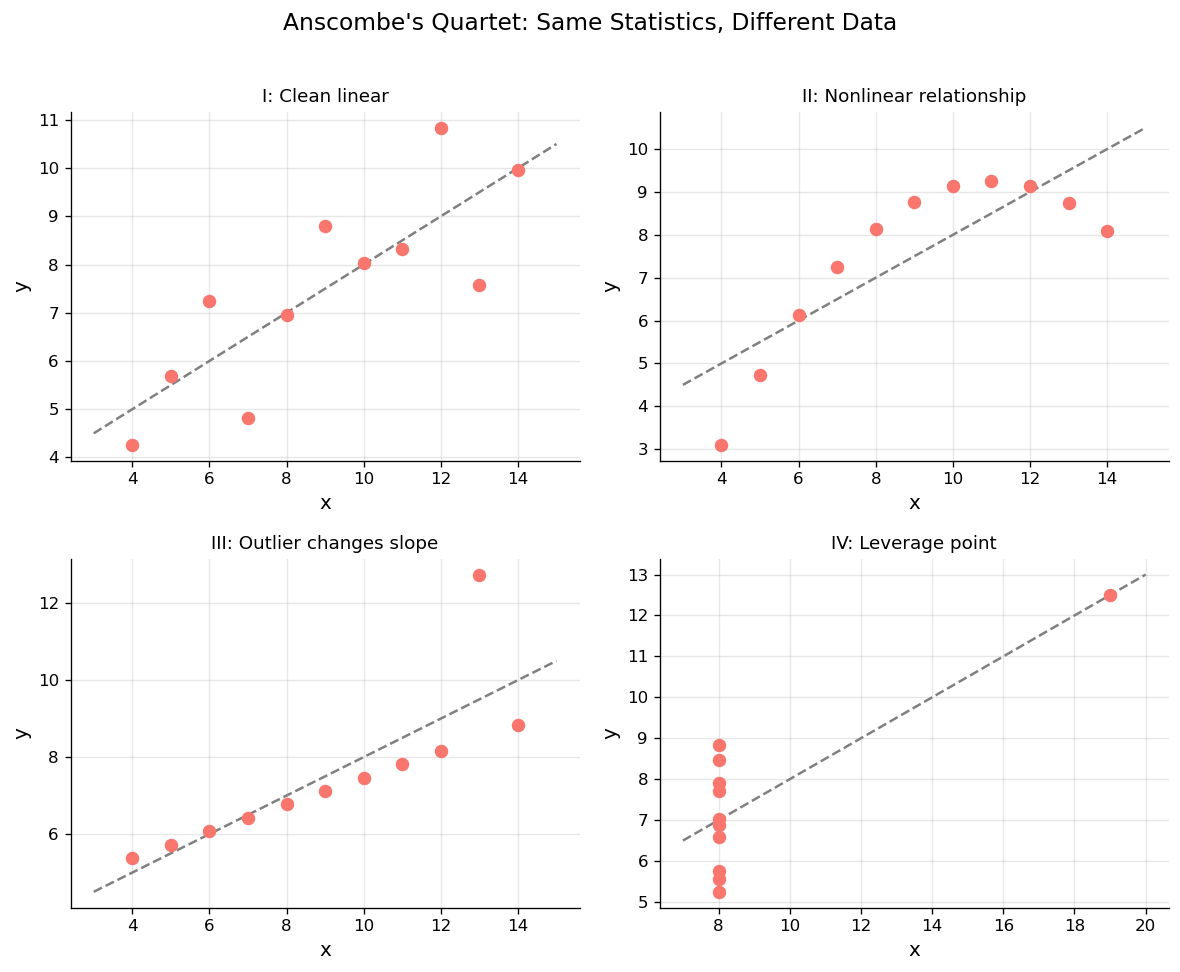

In [7]:
# Plot the four datasets
fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=False, sharey=False)
titles = [
    "I: Clean linear",
    "II: Nonlinear relationship",
    "III: Outlier changes slope",
    "IV: Leverage point",
]

for idx, ax in enumerate(axes.flat):
    x = np.array(anscombe_x[idx], dtype=float)
    y = np.array(anscombe_y[idx], dtype=float)
    ax.scatter(x, y, s=50, zorder=3)

    # Fit and plot regression line
    slope, intercept = np.polyfit(x, y, 1)
    x_line = np.linspace(x.min() - 1, x.max() + 1, 100)
    ax.plot(x_line, intercept + slope * x_line, "--", color="grey", linewidth=1.5)

    ax.set_title(titles[idx], fontsize=11)
    ax.set_xlabel("x")
    ax.set_ylabel("y")

plt.suptitle("Anscombe's Quartet: Same Statistics, Different Data", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

All four datasets have nearly the same mean, variance, correlation, and regression line. Yet:
- **Dataset I** is a clean linear relationship — the statistics are appropriate.
- **Dataset II** has a clear nonlinear pattern — a straight line is the wrong model.
- **Dataset III** has a near-perfect linear relationship disrupted by a single outlier.
- **Dataset IV** is entirely determined by one leverage point.

The lesson is fundamental: **compute your statistics, but always look at your data**. We'll explore this principle further in the next notebook on data exploration.

---

## 6. The Five-Number Summary and Box Plots

A compact description of a dataset:

$$\text{Min}, \quad Q_1, \quad \text{Median}, \quad Q_3, \quad \text{Max}$$

The **box plot** (or box-and-whisker plot) visualises this summary. It shows the median, the IQR (the box), and outliers (points beyond $1.5 \times \text{IQR}$ from the box).

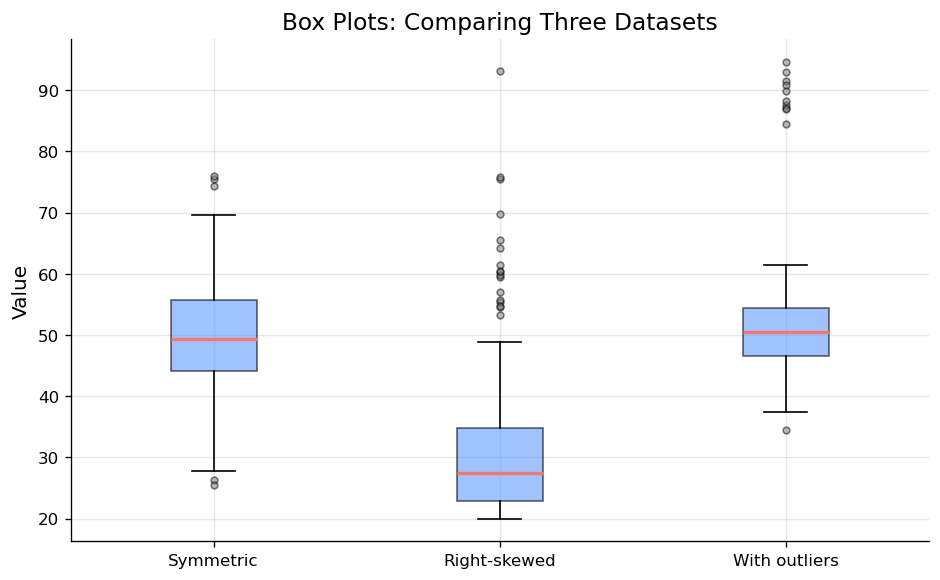

Symmetric   : min=25.5, Q1=44.2, median=49.4, Q3=55.8, max=76.0
Skewed      : min=20.0, Q1=22.9, median=27.4, Q3=34.8, max=93.2
Outliers    : min=34.5, Q1=46.6, median=50.5, Q3=54.4, max=94.6


In [7]:
# Generate three datasets with different characteristics
data_sym = rng.normal(50, 10, 200)
data_skew = rng.exponential(10, 200) + 20
data_outliers = np.concatenate([rng.normal(50, 5, 190), rng.normal(90, 3, 10)])

fig, ax = plt.subplots(figsize=(8, 5))
bp = ax.boxplot(
    [data_sym, data_skew, data_outliers],
    tick_labels=["Symmetric", "Right-skewed", "With outliers"],
    patch_artist=True,
    boxprops=dict(facecolor="#619CFF", alpha=0.6),
    medianprops=dict(color="#F8766D", linewidth=2),
    flierprops=dict(marker="o", markerfacecolor="grey", markersize=4, alpha=0.5),
)
ax.set_ylabel("Value")
ax.set_title("Box Plots: Comparing Three Datasets")
plt.tight_layout()
plt.show()

# Five-number summary
for name, d in [
    ("Symmetric", data_sym),
    ("Skewed", data_skew),
    ("Outliers", data_outliers),
]:
    q1, q3 = np.percentile(d, [25, 75])
    print(
        f"{name:12s}: min={d.min():.1f}, Q1={q1:.1f}, median={np.median(d):.1f}, Q3={q3:.1f}, max={d.max():.1f}"
    )

Box plots are especially useful for **comparing distributions side by side**. The box width (IQR), median position, and whisker extent give a quick visual summary.

---

## 7. Summary Table

| Statistic        | Measures | Robust? | From scratch            | NumPy/Pandas              |
|------------------|----------|---------|-------------------------|---------------------------|
| Mean             | Centre   | No      | `sum(x)/len(x)`         | `np.mean(x)`              |
| Median           | Centre   | Yes     | Sort + middle           | `np.median(x)`            |
| Variance ($s^2$) | Spread   | No      | Loop + Bessel           | `np.var(x, ddof=1)`       |
| Std dev ($s$)    | Spread   | No      | $\sqrt{s^2}$            | `np.std(x, ddof=1)`       |
| IQR              | Spread   | Yes     | $Q_3 - Q_1$             | `scipy.stats.iqr(x)`      |
| Skewness         | Shape    | No      | 3rd standardised moment | `scipy.stats.skew(x)`     |
| Kurtosis         | Shape    | No      | 4th standardised moment | `scipy.stats.kurtosis(x)` |

---

## Exercises

**Exercise 1.1 (From scratch).** Implement `skewness_scratch(data)` and `kurtosis_scratch(data)` using loops. Verify against `scipy.stats.skew()` and `scipy.stats.kurtosis()`.

**Exercise 1.2 (Bessel's correction).** Generate 10,000 samples of size $n = 5$ from $\mathcal{N}(0, 1)$. For each, compute the variance with $n$ and with $n-1$ in the denominator. Which estimator's average is closer to the true variance $\sigma^2 = 1$? This is a preview of Module 04.

**Exercise 1.3 (Outlier sensitivity).** Given the data `[2, 3, 4, 5, 6, 7, 8, 100]`, compute the mean, median, variance, and IQR. Now remove the outlier and recompute. Which statistics changed the most?

**Exercise 1.4 (Weighted mean).** A student's grades are: Exam 1 = 85 (weight 30%), Exam 2 = 72 (weight 30%), Final = 91 (weight 40%). Compute the weighted mean from scratch. Then verify with `np.average(grades, weights=weights)`.

**Exercise 1.5 (Anscombe extended).** The **Datasaurus Dozen** (by Justin Matejka and George Fitzmaurice, 2017) extends Anscombe's idea to 13 datasets. Search for it online, load it, and compute summary statistics for each. Do they match? Plot them.

---

## Key Takeaways

1. **Mean** is the standard centre measure but sensitive to outliers; **median** is robust.
2. **Sample variance** uses $n-1$ (Bessel's correction) to be unbiased. Always specify `ddof`.
3. **Skewness** and **kurtosis** quantify departures from symmetry and Normal-like tails.
4. **Anscombe's quartet** proves that summary statistics alone can be misleading — always visualise.
5. **Box plots** provide a compact visual summary: median, IQR, and outliers at a glance.

**Next:** [02_data_exploration.ipynb](02_data_exploration.ipynb) — Exploratory data analysis: the art and practice of understanding data through systematic visualisation.

In [ ]:
cfg.save_gifs(clean=True)